In [7]:
#Loading the dataset
words = open("names.txt", "r").read().split()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [8]:
len(words), min(len(w) for w in words), max(len(w) for w in words)

(32033, 2, 15)

In [9]:
#Integer to Character mapping and the opposite 
itos = {i+1:j for i,j in enumerate(sorted(list(set("".join(words)))))}
itos[0]='.'
stoi = {j:i for i,j in itos.items()}

In [10]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [11]:
#Counting which character follows which for the entire dataset
n=2
count = {}
for w in words:
    word = ['.']*(n-1) + list(w) + ['.']
    for i in range(len(word)-n+1):
        context = tuple(word[i:n+i-1])
        target = word[n+i-1]
        count[(context,target)] = count.get((context,target), 0) + 1
        #print(context, "->",target)


In [12]:
sorted(count.items(), key=lambda item: item[1], reverse=True)

[((('n',), '.'), 6763),
 ((('a',), '.'), 6640),
 ((('a',), 'n'), 5438),
 ((('.',), 'a'), 4410),
 ((('e',), '.'), 3983),
 ((('a',), 'r'), 3264),
 ((('e',), 'l'), 3248),
 ((('r',), 'i'), 3033),
 ((('n',), 'a'), 2977),
 ((('.',), 'k'), 2963),
 ((('l',), 'e'), 2921),
 ((('e',), 'n'), 2675),
 ((('l',), 'a'), 2623),
 ((('m',), 'a'), 2590),
 ((('.',), 'm'), 2538),
 ((('a',), 'l'), 2528),
 ((('i',), '.'), 2489),
 ((('l',), 'i'), 2480),
 ((('i',), 'a'), 2445),
 ((('.',), 'j'), 2422),
 ((('o',), 'n'), 2411),
 ((('h',), '.'), 2409),
 ((('r',), 'a'), 2356),
 ((('a',), 'h'), 2332),
 ((('h',), 'a'), 2244),
 ((('y',), 'a'), 2143),
 ((('i',), 'n'), 2126),
 ((('.',), 's'), 2055),
 ((('a',), 'y'), 2050),
 ((('y',), '.'), 2007),
 ((('e',), 'r'), 1958),
 ((('n',), 'n'), 1906),
 ((('y',), 'n'), 1826),
 ((('k',), 'a'), 1731),
 ((('n',), 'i'), 1725),
 ((('r',), 'e'), 1697),
 ((('.',), 'd'), 1690),
 ((('i',), 'e'), 1653),
 ((('a',), 'i'), 1650),
 ((('.',), 'r'), 1639),
 ((('a',), 'm'), 1634),
 ((('l',), 'y'),

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
vocab_size = len(stoi)
N = np.zeros((vocab_size, vocab_size))

In [15]:
for i,j in count.items():
    row = stoi[i[0][0]]
    col = stoi[i[1]]
    N[row,col] += j

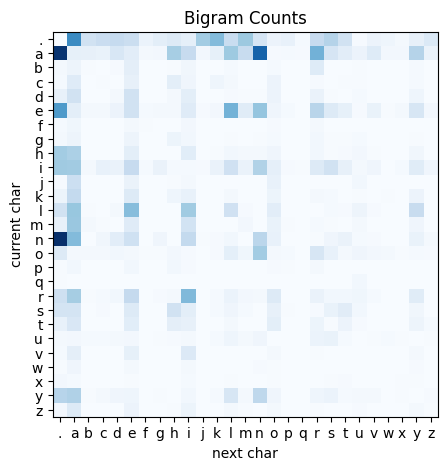

In [16]:
plt.figure(figsize=(5,5))
plt.imshow(N, cmap='Blues')

# ticks
plt.xticks(range(len(itos)), [itos[i] for i in range(len(itos))])
plt.yticks(range(len(itos)), [itos[i] for i in range(len(itos))])

plt.xlabel("next char")
plt.ylabel("current char")
plt.title("Bigram Counts")
plt.show()

In [17]:
N = N + 1
P = N/ N.sum(axis=1, keepdims=True) 

In [18]:
loss = 0
total = 0
for (context, target), cnt in count.items():
    row = stoi[context[0]]
    col = stoi[target]
    loss += cnt * np.log(P[row,col])
    total += cnt  

loss = -loss/total  
loss

2.454576820115698

In [19]:
s = stoi['.']
for i in range(10):
    new = []
    char = ""
    while (char!='.'):
        idx = np.random.choice(vocab_size, p=P[s])
        char = itos[idx]
        s = idx
        new.append(char)
    print(''.join(new))

dens.
ma.
leyl.
ane.
amaash.
slytosmaya.
bradonir.
y.
h.
kazuigikhikon.
